11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


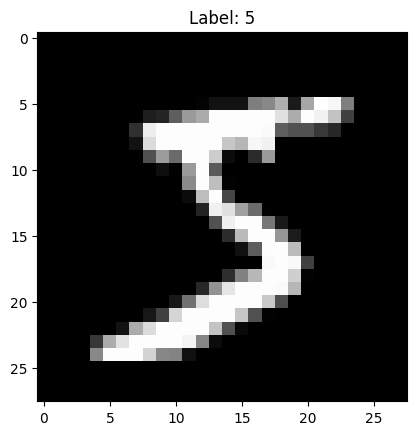

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Step 1: Load Dataset [cite: 20]
# This splits the data into training and testing sets automatically [cite: 22]
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Quick check of the data dimensions [cite: 13]
print(f"Training images: {x_train.shape}") # Should be (60000, 28, 28) [cite: 15, 17]
print(f"Testing images: {x_test.shape}")   # Should be (10000, 28, 28) [cite: 16]

# Visualize one digit to make sure it looks right
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

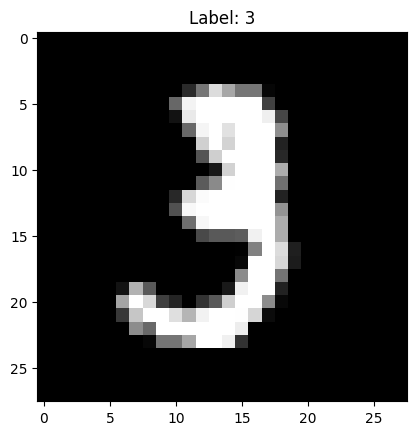

In [ ]:

plt.imshow(x_train[10], cmap='gray')
plt.title(f"Label: {y_train[10]}")
plt.show()

In [ ]:
# --- STEP 2: PREPROCESSING ---

# 1. Normalization (0–255 → 0–1)
# We divide by 255.0 to turn pixel values into decimals between 0 and 1.
# This helps the model learn much faster.
x_train = x_train / 255.0
x_test = x_test / 255.0

# 2. Flattening (28x28 → 784)
# A dense neural network needs a flat list of numbers, not a square image.
# 28 pixels * 28 pixels = 784 total pixels[cite: 17, 31].
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

# Print the results to confirm
print(f"Original shape: {x_train.shape}")      # (60000, 28, 28)
print(f"Flattened shape: {x_train_flat.shape}") # (60000, 784)

Original shape: (60000, 28, 28)
Flattened shape: (60000, 784)


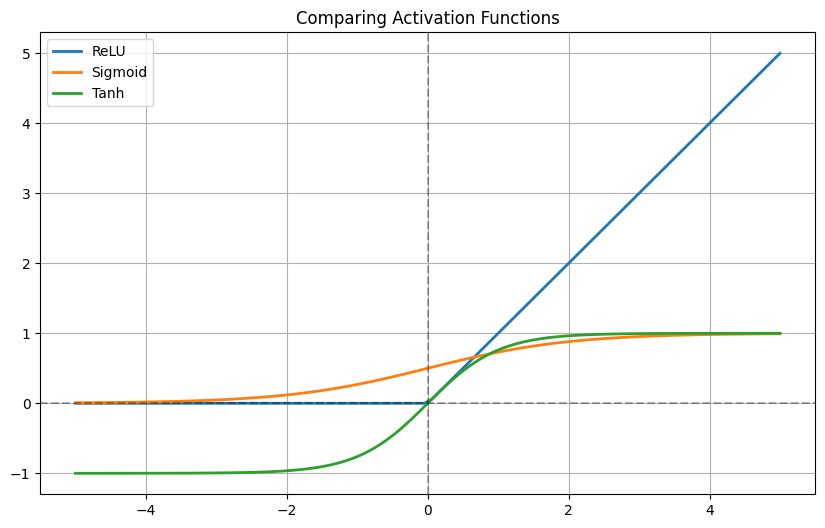

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Create a range of numbers from -5 to 5
inputs = np.linspace(-5, 5, 100)

# Calculate the outputs for each function
relu_out = tf.keras.activations.relu(inputs).numpy()
sigmoid_out = tf.keras.activations.sigmoid(inputs).numpy()
tanh_out = tf.keras.activations.tanh(inputs).numpy()

# Plot them to compare behavior (Step 3 - Compare performance)
plt.figure(figsize=(10, 6))
plt.plot(inputs, relu_out, label='ReLU', linewidth=2)
plt.plot(inputs, sigmoid_out, label='Sigmoid', linewidth=2)
plt.plot(inputs, tanh_out, label='Tanh', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Comparing Activation Functions")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras import layers, models

# Initialize the model as a 'Sequential' stack (layer by layer)
model = models.Sequential([
    # Input Layer (Flattened image data)
    layers.Input(shape=(784,)),

    # Hidden Layer 1: 128 neurons with ReLU activation
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Hidden Layer 2: 64 neurons with ReLU activation
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    # Output Layer: 10 neurons with Softmax activation
    layers.Dense(10, activation='softmax')
])

# This command shows you a summary of the 'brain' you just created
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- STEP 5: COMPILE MODEL ---

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model is compiled and ready to train!")

Model is compiled and ready to train!


In [ ]:
# --- STEP 6: TRAIN MODEL ---

# We use the flattened data we created in Step 2
history = model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8683 - loss: 0.4354 - val_accuracy: 0.9507 - val_loss: 0.1677
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9365 - loss: 0.2168 - val_accuracy: 0.9607 - val_loss: 0.1338
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9487 - loss: 0.1766 - val_accuracy: 0.9677 - val_loss: 0.1088
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9566 - loss: 0.1460 - val_accuracy: 0.9713 - val_loss: 0.0999
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9603 - loss: 0.1309 - val_accuracy: 0.9701 - val_loss: 0.0995
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9632 - loss: 0.1220 - val_accuracy: 0.9738 - val_loss: 0.0941
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9666 - loss: 0.1122 - val_accuracy: 0.9714 - val_loss: 0.0988
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9682 - loss: 0.1040 - 

In [ ]:
import numpy as np

# Pick one image from the test set (e.g., the first one)
sample_image = x_test_flat[0:1]
actual_label = y_test[0]

# Forward Propagation: The model takes the input and generates a prediction
prediction = model.predict(sample_image)
predicted_label = np.argmax(prediction)

print(f"Actual Digit: {actual_label}")
print(f"Model's Prediction: {predicted_label}")
print(f"Confidence Scores for all 10 digits:\n{prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
Actual Digit: 7
Model's Prediction: 7
Confidence Scores for all 10 digits:
[[1.1683727e-12 2.1890223e-10 3.6098211e-08 2.3579307e-06 3.6496710e-15
  2.0093980e-08 1.4215797e-17 9.9999750e-01 4.8255189e-12 6.8484340e-08]]


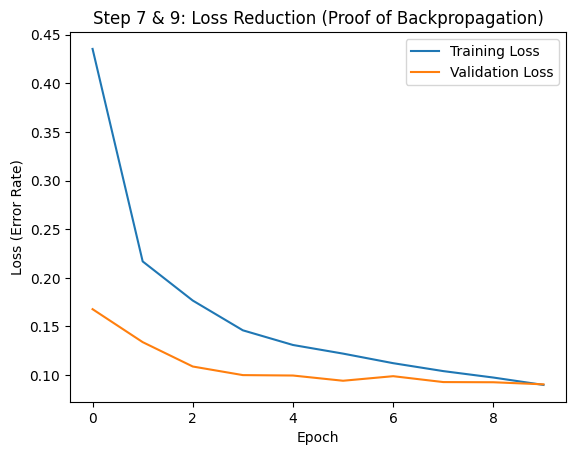

In [ ]:
# Plotting the "Learning Curve" to show Backpropagation in action
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Step 7 & 9: Loss Reduction (Proof of Backpropagation)')
plt.ylabel('Loss (Error Rate)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

Final Test Accuracy: 97.57%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


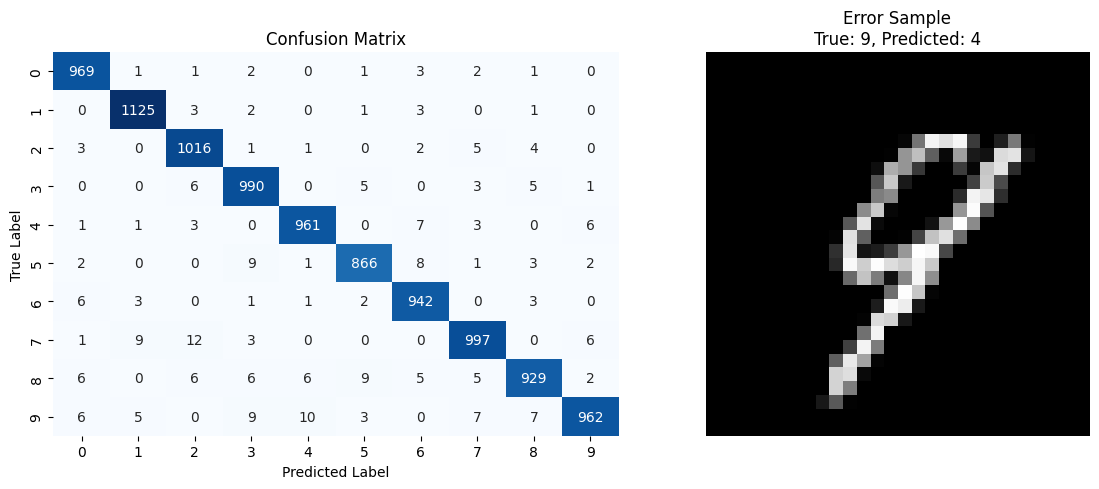

In [ ]:
# --- STEP 8: ENTIRE EVALUATION PERFORMANCE ---
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Final Accuracy Check [cite: 46]
# This tests the model on 10,000 images it has never seen before [cite: 16]
test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

# 2. Generate Predictions [cite: 43]
# The model takes a guess for every image in the test set
y_pred = model.predict(x_test_flat)
y_pred_classes = np.argmax(y_pred, axis=1) # Pick the digit with the highest probability [cite: 34]

# 3. Create the Confusion Matrix
# This shows exactly which digits were confused with others [cite: 64]
cm = confusion_matrix(y_test, y_pred_classes)

# 4. Plotting the Results
plt.figure(figsize=(12, 5))

# Plot A: Confusion Matrix Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Plot B: Visualizing a Misclassification [cite: 48, 65]
# Let's find the first image where the model made a mistake
errors = np.where(y_pred_classes != y_test)[0]
if len(errors) > 0:
    plt.subplot(1, 2, 2)
    idx = errors[0]
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Error Sample\nTrue: {y_test[idx]}, Predicted: {y_pred_classes[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

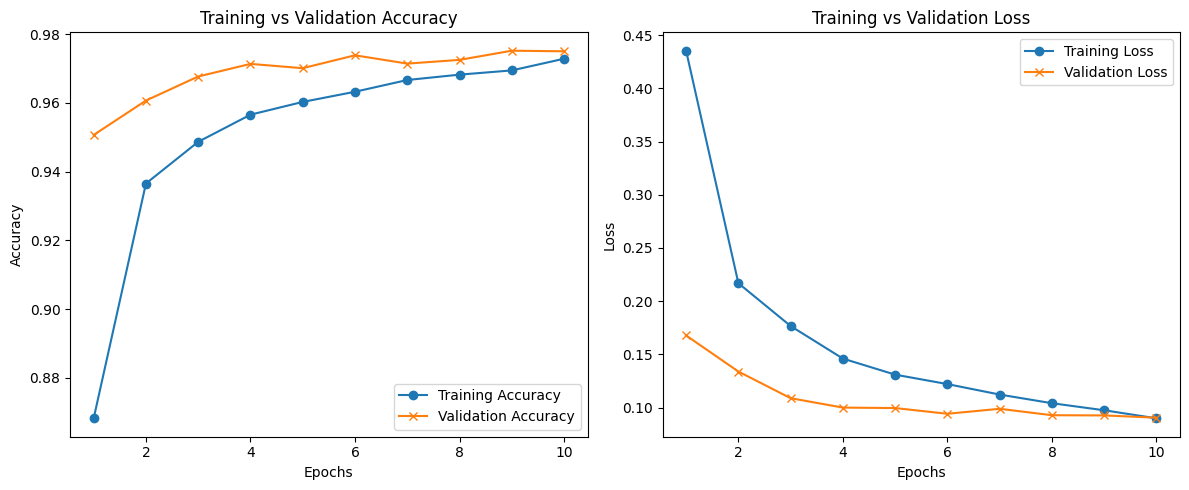

Final Training Accuracy: 97.28%
Final Validation Accuracy: 97.50%
Difference (Gap): -0.22%


In [ ]:
# --- STEP 9: ANALYZE OVERFITTING ---
import matplotlib.pyplot as plt

# 1. Extract accuracy and loss values from the 'history' object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# 2. Create the plots
plt.figure(figsize=(12, 5))

# Plot A: Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot B: Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Final Check
print(f"Final Training Accuracy: {acc[-1]*100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1]*100:.2f}%")
print(f"Difference (Gap): {(acc[-1] - val_acc[-1])*100:.2f}%")

In [ ]:
from google.colab import files
from PIL import Image
import numpy as np

# 1. Upload your own image file (e.g., a .png or .jpg of a digit)
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Open and convert to grayscale
    img = Image.open(filename).convert('L')

    # 3. Resize to 28x28 (the size the model expects)
    img = img.resize((28, 28))

    # 4. Convert to array and normalize (0-1)
    img_array = np.array(img) / 255.0

    # 5. Invert if necessary (MNIST has white digits on black background)
    # If your image is black ink on white paper, we must flip it.
    if np.mean(img_array) > 0.5:
        img_array = 1.0 - img_array

    # 6. Flatten and Predict
    img_flat = img_array.reshape(1, 784)
    prediction = model.predict(img_flat)
    result = np.argmax(prediction)

    # 7. Show the result
    plt.imshow(img_array, cmap='gray')
    plt.title(f"I think this is a: {result}")
    plt.show()